In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Function to extract k-mers from DNA sequence
def extract_kmers(sequence, k=5):
    kmers = [sequence[i:i+k] for i in range(len(sequence) - k + 1)]
    return ' '.join(kmers)

# Load the dataset
df = pd.read_csv("DNA.csv")

# Step 1: Preprocess the data (Convert DNA sequences into k-mer frequencies)
k = 5  # You can experiment with different k values (e.g., 3, 4, 5, 6)
df['kmers'] = df['sequence'].apply(lambda seq: extract_kmers(seq, k))

# Step 2: TF-IDF Vectorization
vectorizer = TfidfVectorizer(analyzer='word')
X = vectorizer.fit_transform(df['kmers'])

# Step 3: Train the first classifier to predict the species
X_train, X_test, y_train, y_test = train_test_split(X, df['species'], test_size=0.3, random_state=42)

# Trying RandomForestClassifier instead of Naive Bayes for species classification
species_classifier = RandomForestClassifier(random_state=42)
species_classifier.fit(X_train, y_train)

# Make predictions and evaluate the species classifier
species_predictions = species_classifier.predict(X_test)
species_accuracy = accuracy_score(y_test, species_predictions)
print(f"Species Classifier Accuracy: {species_accuracy}")

# Step 4: Train a separate classifier for each species to predict the class
# Create dictionaries to store classifiers for each species
classifiers = {}

for species in df['species'].unique():
    # Filter the data for the current species
    species_data = df[df['species'] == species]
    X_species = vectorizer.transform(species_data['kmers'])
    y_species = species_data['class']
    
    # Split the data into train and test sets
    X_train_species, X_test_species, y_train_species, y_test_species = train_test_split(X_species, y_species, test_size=0.3, random_state=42)
    
    # Try Random Forest for class classification as well
    class_classifier = RandomForestClassifier(random_state=42)
    class_classifier.fit(X_train_species, y_train_species)
    
    # Store the classifier in the dictionary
    classifiers[species] = class_classifier
    
    # Make predictions and evaluate the class classifier
    class_predictions = class_classifier.predict(X_test_species)
    class_accuracy = accuracy_score(y_test_species, class_predictions)
    print(f"Class Classifier Accuracy for {species}: {class_accuracy}")



Species Classifier Accuracy: 0.6058111380145278
Class Classifier Accuracy for Human: 0.830289193302892
Class Classifier Accuracy for Dog: 0.6382113821138211
Class Classifier Accuracy for Chimp: 0.8316831683168316


In [13]:
# Example of how to use the trained models for predictions
def predict_species_and_class(sequence):
    # Convert the sequence into k-mer frequencies
    sequence_kmers = extract_kmers(sequence, k)
    sequence_vector = vectorizer.transform([sequence_kmers])
    
    # Predict the species first
    predicted_species = species_classifier.predict(sequence_vector)[0]
    
    # Predict the class within the predicted species
    class_classifier = classifiers[predicted_species]
    predicted_class = class_classifier.predict(sequence_vector)[0]
    
    return predicted_species, predicted_class

# Test prediction with a sample DNA sequence
sample_sequence = "CAGCAGCAGGGTGG"
predicted_species, predicted_class = predict_species_and_class(sample_sequence)
print(f"Predicted Species: {predicted_species}, Predicted Class: {predicted_class}")


Predicted Species: Human, Predicted Class: 6


In [10]:
import pickle

# Save the species classifier using pickle
with open('species_classifier.pkl', 'wb') as f:
    pickle.dump(species_classifier, f)

# Save each class classifier (one for each species) using pickle
for species, classifier in classifiers.items():
    with open(f'{species}_class_classifier.pkl', 'wb') as f:
        pickle.dump(classifier, f)

# Save the TF-IDF vectorizer as well
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Models and vectorizer saved successfully!")


Models and vectorizer saved successfully!


In [14]:
# Load the saved species classifier
with open('species_classifier.pkl', 'rb') as f:
    loaded_species_classifier = pickle.load(f)

# Load the class-specific classifiers
loaded_classifiers = {}
for species in ['human', 'dog', 'chimp']:  # Ensure these match the saved classifiers
    with open(f'{species}_class_classifier.pkl', 'rb') as f:
        loaded_classifiers[species] = pickle.load(f)

# Load the TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_vectorizer = pickle.load(f)

print("Models and vectorizer loaded successfully!")


Models and vectorizer loaded successfully!


C:\Users\Main Python2\AppData\Local\Temp\ipykernel_14556\828793304.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['species'], palette='viridis')


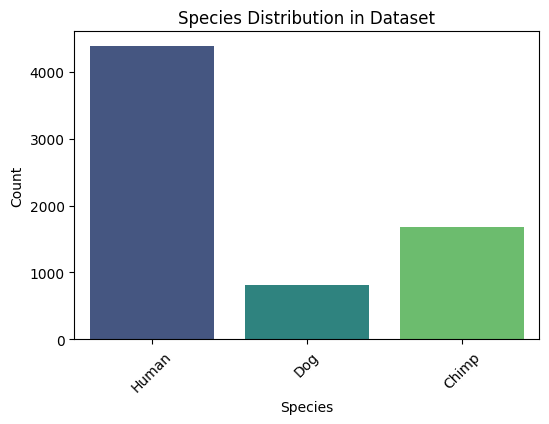

C:\Users\Main Python2\AppData\Local\Temp\ipykernel_14556\828793304.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['class'], palette='coolwarm')


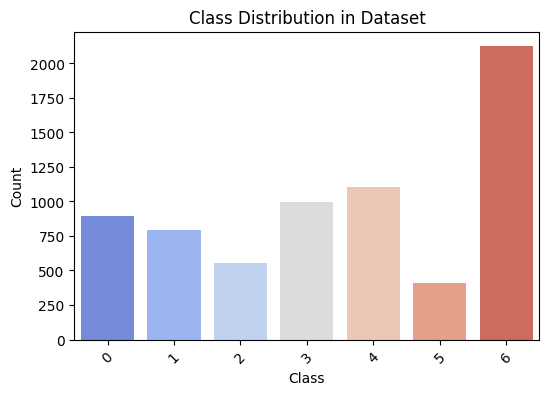

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Species Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['species'], palette='viridis')
plt.xlabel("Species")
plt.ylabel("Count")
plt.title("Species Distribution in Dataset")
plt.xticks(rotation=45)
plt.show()

# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['class'], palette='coolwarm')
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution in Dataset")
plt.xticks(rotation=45)
plt.show()


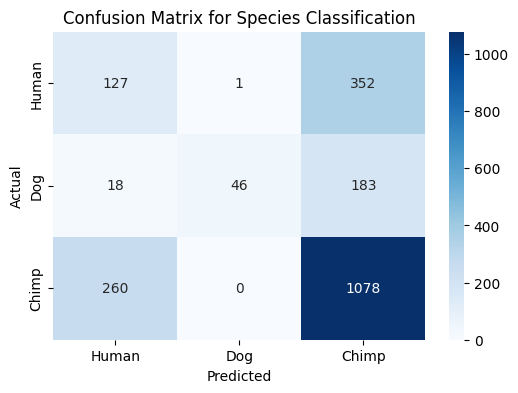

In [19]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, species_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df['species'].unique(), yticklabels=df['species'].unique())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Species Classification")
plt.show()


C:\Users\Main Python2\AppData\Local\Temp\ipykernel_14556\1312719051.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=species_names, y=class_accuracies, palette='coolwarm')


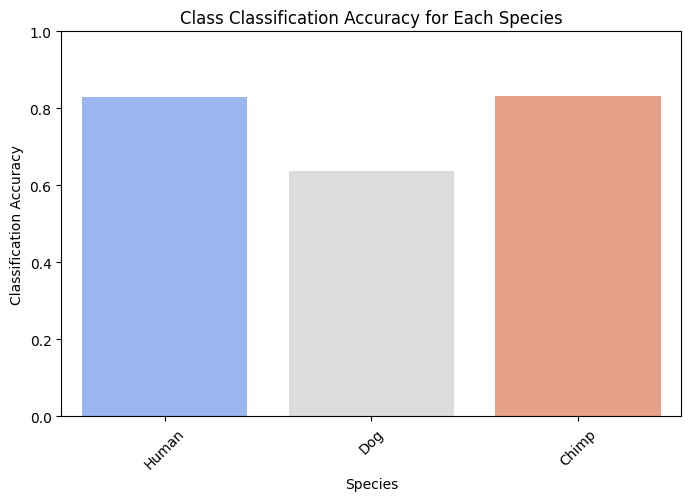

In [20]:
species_names = list(classifiers.keys())
class_accuracies = []

for species in species_names:
    species_data = df[df['species'] == species]
    X_species = vectorizer.transform(species_data['kmers'])
    y_species = species_data['class']
    
    X_train_species, X_test_species, y_train_species, y_test_species = train_test_split(X_species, y_species, test_size=0.3, random_state=42)
    
    class_predictions = classifiers[species].predict(X_test_species)
    class_accuracy = accuracy_score(y_test_species, class_predictions)
    
    class_accuracies.append(class_accuracy)

plt.figure(figsize=(8,5))
sns.barplot(x=species_names, y=class_accuracies, palette='coolwarm')
plt.xlabel("Species")
plt.ylabel("Classification Accuracy")
plt.title("Class Classification Accuracy for Each Species")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()
